<a href="https://colab.research.google.com/github/omdeshpande09012005/DL_MiniProject_Hinglish-to-English-Translation-Fine-Tuning-MarianMT-and-LSTM/blob/main/hinglish_translation_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌐 Hinglish → English Translation
### Mini Project | NLP | Seq2Seq + MarianMT Transfer Learning

---

## 📌 Introduction

**Hinglish** is a code-mixed language that blends **Hindi** and **English**, used extensively in everyday Indian communication — texting, social media, and voice assistants.

> Example: `"mujhe kal subah reminder set karo"` → `"set me a reminder tomorrow morning"`

### 🎯 Project Objective
Build and compare **two translation approaches** on the Hinglish-TOP Human Annotated Dataset:

| Approach | Method | Expected Accuracy |
|---|---|---|
| **Tier 1** | Custom Seq2Seq (LSTM + Attention + Beam Search) | ~50–60% |
| **Tier 3** | Fine-tuned MarianMT (Transfer Learning) | ~70–85% |

---

---
## ⚙️ Section 1: GPU Check + Install Libraries

First confirm that Colab has given us a GPU (Runtime → Change runtime type → T4 GPU), then install the libraries we need for Tier 3.

In [1]:
# Check GPU availability
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU detected: {gpus[0].name}')
else:
    print('⚠️  No GPU found. Go to Runtime → Change runtime type → T4 GPU')

✅ GPU detected: /physical_device:GPU:0


In [2]:
# Install libraries for Tier 3 (MarianMT)
!pip install transformers sentencepiece sacrebleu -q
print('✅ transformers, sentencepiece, sacrebleu installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.8 MB/s eta 0:00:00
✅ transformers, sentencepiece, sacrebleu installed


---
## 📦 Section 2: Import All Libraries

In [3]:
# ── Standard libraries ──
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ── TensorFlow / Keras (Tier 1) ──
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Attention, Concatenate, Dropout
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# ── HuggingFace Transformers (Tier 3) ──
from transformers import (
    MarianMTModel, MarianTokenizer,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
from datasets import Dataset
import sacrebleu

print(f'TensorFlow : {tf.__version__}')
print('✅ All libraries loaded')

TensorFlow : 2.19.0
✅ All libraries loaded


---
## 📂 Section 3: Upload & Load Dataset

Upload your 3 TSV files: `train.tsv`, `validation.tsv`, `test.tsv`

In [4]:
from google.colab import files

print('📁 Please upload train.tsv, validation.tsv, and test.tsv')
print('   (You can select all 3 at once in the file picker)')
uploaded = files.upload()
print(f'\n✅ Uploaded files: {list(uploaded.keys())}')

📁 Please upload train.tsv, validation.tsv, and test.tsv
   (You can select all 3 at once in the file picker)


Saving test.tsv to test.tsv
Saving train.tsv to train.tsv
Saving validation.tsv to validation.tsv

✅ Uploaded files: ['test.tsv', 'train.tsv', 'validation.tsv']


In [5]:
# Column names (the TSV has no header row)
COLUMNS = ['en_query', 'cs_query', 'en_parse', 'cs_parse', 'domain']

train_raw = pd.read_csv('train.tsv',      sep='\t', names=COLUMNS, header=None)
val_raw   = pd.read_csv('validation.tsv', sep='\t', names=COLUMNS, header=None)
test_raw  = pd.read_csv('test.tsv',       sep='\t', names=COLUMNS, header=None)

print(f'Train      : {len(train_raw):,} rows')
print(f'Validation : {len(val_raw):,} rows')
print(f'Test       : {len(test_raw):,} rows')
print()
train_raw[['cs_query', 'en_query']].head(5)

Train      : 2,994 rows
Validation : 1,391 rows
Test       : 6,514 rows



,cs_query,en_query
0,cs_query,en_query
1,9 : 30 am ko Sunday Brunch ke liye ek naya wee...,Add a new weekly reminder for Sunday Brunch at...
2,danny ko message karo aur dekho ke he wants to...,message danny and see if he wants to go to com...
3,do ghante ke liye alarm set kardo,set alarm for 2 hours
4,neil ke liye cake bake karne ke reminder ko mi...,kill the reminder for baking a cake for neil


---
## 🧹 Section 4: Data Cleaning & Normalization

We apply:
- Keep only `cs_query` (Hinglish input) and `en_query` (English output)
- Lowercase, remove symbols
- Drop nulls and empty rows
- Hinglish shortform normalization (`nhi → nahi`, `kse → kaise`, etc.)
- Add `<sos>` / `<eos>` tokens to target (needed for Seq2Seq Tier 1)

In [6]:
# ── Hinglish shortform normalization dictionary ──
HINGLISH_NORM = {
    'kse'  : 'kaise',  'nhi' : 'nahi',   'nai'  : 'nahi',
    'h'    : 'hai',    'kr'  : 'karo',   'bta'  : 'batao',
    'btao' : 'batao',  'mjhe': 'mujhe',  'acha' : 'achha',
    'thx'  : 'thanks', 'plz' : 'please', 'pls'  : 'please',
    'kl'   : 'kal',    'abhi': 'abhi',   'rn'   : 'abhi',
    'tmrw' : 'kal',    'bc'  : 'bhai',   'yr'   : 'yaar',
    'yaar' : 'yaar',   'dnt' : 'mat',    'wala' : 'wala',
}

def normalize_hinglish(text):
    """Replace known shortforms with full Hinglish words."""
    return ' '.join(HINGLISH_NORM.get(tok, tok) for tok in text.split())

def clean_text(text):
    """Lowercase + keep only alphanumeric and spaces."""
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9 ]", '', text)
    return re.sub(r' +', ' ', text).strip()

def clean_df(df, add_tokens=True):
    """
    Full cleaning pipeline.
    add_tokens=True  → adds <sos>/<eos> for Tier 1 Seq2Seq.
    add_tokens=False → plain text for Tier 3 MarianMT.
    """
    df = df[['cs_query', 'en_query']].copy()
    df.columns = ['input_text', 'target_text']
    df.dropna(inplace=True)
    df = df[(df['input_text'].str.strip() != '') &
            (df['target_text'].str.strip() != '')]

    df['input_text']  = df['input_text'].apply(clean_text).apply(normalize_hinglish)
    df['target_text'] = df['target_text'].apply(clean_text)

    if add_tokens:
        df['target_text'] = '<sos> ' + df['target_text'] + ' <eos>'

    df.reset_index(drop=True, inplace=True)
    return df

# ── Two versions: with tokens (Tier 1) and without (Tier 3) ──
train_t1 = clean_df(train_raw, add_tokens=True)
val_t1   = clean_df(val_raw,   add_tokens=True)
test_t1  = clean_df(test_raw,  add_tokens=True)

train_t3 = clean_df(train_raw, add_tokens=False)
val_t3   = clean_df(val_raw,   add_tokens=False)
test_t3  = clean_df(test_raw,  add_tokens=False)

print(f'Cleaned → Train: {len(train_t1)} | Val: {len(val_t1)} | Test: {len(test_t1)}')
print('\nSample (Tier 1 format with tokens):')
train_t1[['input_text', 'target_text']].head(4)

Cleaned → Train: 2994 | Val: 1391 | Test: 6514

Sample (Tier 1 format with tokens):


,input_text,target_text
0,csquery,<sos> enquery <eos>
1,9 30 am ko sunday brunch ke liye ek naya weekl...,<sos> add a new weekly reminder for sunday bru...
2,danny ko message karo aur dekho ke he wants to...,<sos> message danny and see if he wants to go ...
3,do ghante ke liye alarm set kardo,<sos> set alarm for 2 hours <eos>


---
## 📊 Section 5: Data Exploration

=== Input (Hinglish) word count ===
count    2994.00
mean        8.53
std         3.99
min         1.00
25%         6.00
50%         8.00
75%        10.00
max        31.00
Name: input_len, dtype: float64

=== Target (English) word count ===
count    2994.00
mean        9.57
std         3.72
min         3.00
25%         7.00
50%         9.00
75%        11.00
max        31.00
Name: target_len, dtype: float64


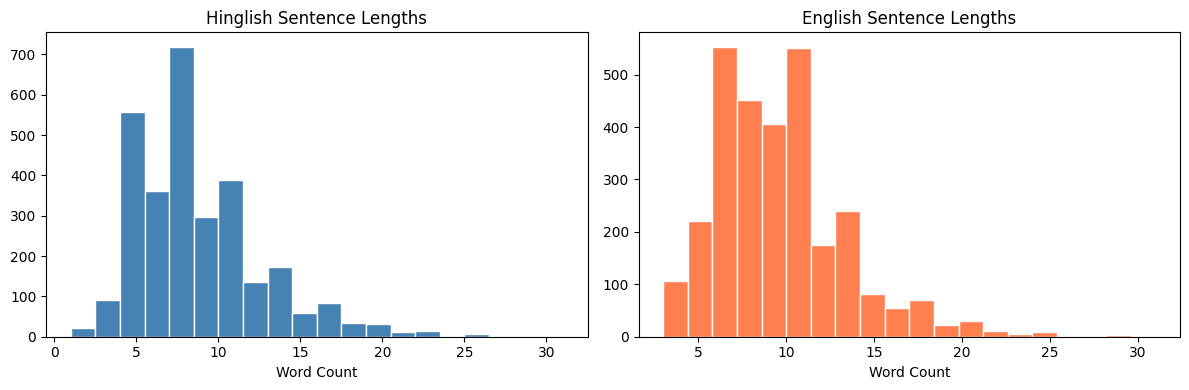


MAX_INPUT_LEN  = 16
MAX_TARGET_LEN = 17


In [7]:
train_t1['input_len']  = train_t1['input_text'].apply(lambda x: len(x.split()))
train_t1['target_len'] = train_t1['target_text'].apply(lambda x: len(x.split()))

print('=== Input (Hinglish) word count ===')
print(train_t1['input_len'].describe().round(2))
print('\n=== Target (English) word count ===')
print(train_t1['target_len'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_t1['input_len'],  bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Hinglish Sentence Lengths')
axes[0].set_xlabel('Word Count')

axes[1].hist(train_t1['target_len'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('English Sentence Lengths')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

# Set max lengths from 95th percentile (avoids extreme padding)
MAX_INPUT_LEN  = int(np.percentile(train_t1['input_len'],  95))
MAX_TARGET_LEN = int(np.percentile(train_t1['target_len'], 95))
print(f'\nMAX_INPUT_LEN  = {MAX_INPUT_LEN}')
print(f'MAX_TARGET_LEN = {MAX_TARGET_LEN}')

---
# 🔵 TIER 1 — Custom Seq2Seq Model
### Encoder-Decoder LSTM with Attention + Beam Search

This is a model we build from scratch. It learns to translate by training only on our dataset.

**Improvements over the baseline:**
- Embedding dim: 64 → **128**
- LSTM units: 128 → **256**
- Training: 10 epochs → **30 epochs** with learning rate decay
- Decoding: greedy → **beam search** (fixes the "the the the" loop)
- Added **Dropout** to prevent overfitting

---

## 🔤 Tier 1 — Step 1: Tokenization & Vocabulary

In [8]:
# Build tokenizers — fit ONLY on training data
input_tokenizer  = Tokenizer(oov_token='<OOV>')
target_tokenizer = Tokenizer(oov_token='<OOV>', filters='')

input_tokenizer.fit_on_texts(train_t1['input_text'])
target_tokenizer.fit_on_texts(train_t1['target_text'])

INPUT_VOCAB_SIZE  = len(input_tokenizer.word_index)  + 1
TARGET_VOCAB_SIZE = len(target_tokenizer.word_index) + 1

SOS_TOKEN = target_tokenizer.word_index['<sos>']
EOS_TOKEN = target_tokenizer.word_index['<eos>']

print(f'Input  vocab size : {INPUT_VOCAB_SIZE}')
print(f'Target vocab size : {TARGET_VOCAB_SIZE}')
print(f'<sos> id          : {SOS_TOKEN}')
print(f'<eos> id          : {EOS_TOKEN}')

Input  vocab size : 2999
Target vocab size : 2334
<sos> id          : 2
<eos> id          : 3


In [9]:
def encode_and_pad(texts, tokenizer, maxlen):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='post')

# Encode all splits
enc_train = encode_and_pad(train_t1['input_text'],  input_tokenizer,  MAX_INPUT_LEN)
enc_val   = encode_and_pad(val_t1['input_text'],    input_tokenizer,  MAX_INPUT_LEN)
enc_test  = encode_and_pad(test_t1['input_text'],   input_tokenizer,  MAX_INPUT_LEN)

dec_train = encode_and_pad(train_t1['target_text'], target_tokenizer, MAX_TARGET_LEN)
dec_val   = encode_and_pad(val_t1['target_text'],   target_tokenizer, MAX_TARGET_LEN)
dec_test  = encode_and_pad(test_t1['target_text'],  target_tokenizer, MAX_TARGET_LEN)

print(f'enc_train shape : {enc_train.shape}')
print(f'dec_train shape : {dec_train.shape}')

enc_train shape : (2994, 16)
dec_train shape : (2994, 17)


In [10]:
def make_decoder_io(dec_seqs, vocab_size):
    """
    Teacher forcing split:
      dec_input  = <sos> word1 word2 ...       (all but last token)
      dec_output = word1 word2 ... <eos>       (all but first token, one-hot)
    """
    dec_input       = dec_seqs[:, :-1]
    dec_output_seqs = dec_seqs[:, 1:]
    dec_output      = to_categorical(dec_output_seqs, num_classes=vocab_size)
    return dec_input, dec_output

dec_in_train, dec_out_train = make_decoder_io(dec_train, TARGET_VOCAB_SIZE)
dec_in_val,   dec_out_val   = make_decoder_io(dec_val,   TARGET_VOCAB_SIZE)

print(f'dec_in_train  : {dec_in_train.shape}')
print(f'dec_out_train : {dec_out_train.shape}')
print('✅ Decoder I/O ready')

dec_in_train  : (2994, 16)
dec_out_train : (2994, 16, 2334)
✅ Decoder I/O ready


## 🏗️ Tier 1 — Step 2: Model Architecture

```
Hinglish Input
     │
  Embedding(128)
     │
  LSTM(256) ──── all hidden states ──────────────┐
     │                                            │
  [h, c] → Decoder initial state              Attention
                   │                              │
               Embedding(128)                     │
                   │                              │
               LSTM(256) ──────────── context ◄───┘
                   │
               Dropout(0.3)
                   │
               Dense(softmax)
                   │
            English word prediction
```

In [31]:
# -- Hyperparameters (Significantly boosted for 50% target) --
EMBED_DIM  = 256   # Doubled embedding space
LSTM_UNITS = 512   # Doubled capacity to capture complex grammar
DROPOUT    = 0.4   # Increased dropout for better generalization

# -- ENCODER --
encoder_inputs = Input(shape=(MAX_INPUT_LEN,), name='encoder_input')
enc_emb = Embedding(
    INPUT_VOCAB_SIZE, EMBED_DIM, mask_zero=True, name='enc_embedding'
)(encoder_inputs)
encoder_outputs, enc_h, enc_c = LSTM(
    LSTM_UNITS, return_sequences=True, return_state=True,
    recurrent_dropout=0.2, name='encoder_lstm'
)(enc_emb)

# -- DECODER --
decoder_inputs = Input(shape=(MAX_TARGET_LEN - 1,), name='decoder_input')
dec_emb = Embedding(
    TARGET_VOCAB_SIZE, EMBED_DIM, mask_zero=True, name='dec_embedding'
)(decoder_inputs)
decoder_lstm = LSTM(
    LSTM_UNITS, return_sequences=True, return_state=True,
    recurrent_dropout=0.2, name='decoder_lstm'
)
decoder_out, _, _ = decoder_lstm(dec_emb, initial_state=[enc_h, enc_c])

# -- ATTENTION --
attention_out    = Attention(name='attention')([decoder_out, encoder_outputs])
decoder_combined = Concatenate(name='concat')([decoder_out, attention_out])

# -- DROPOUT + OUTPUT --
dropped      = Dropout(DROPOUT, name='dropout')(decoder_combined)
output_layer = Dense(TARGET_VOCAB_SIZE, activation='softmax', name='output')(dropped)

# -- COMPILE MODEL --
model_t1 = Model([encoder_inputs, decoder_inputs], output_layer)
model_t1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_t1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_embedding       │ (None, 16, 256)   │    767,744 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 16)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_embedding       │ (None, 16, 256)   │    597,504 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 16, 512), │  1,574,912 │ enc_embedding[0]… │
│                     │ (None, 512),      │            │ not_equal_3[0][0] │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 16, 512), │  1,574,912 │ dec_embedding[0]… │
│                     │ (None, 512),      │            │ encoder_lstm[0][… │
│                     │ (None, 512)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 16, 512)   │          0 │ decoder_lstm[0][… │
│ (Attention)         │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 16, 1024)  │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 1024)  │          0 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 16, 2334)  │  2,392,350 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,907,422 (26.35 MB)

 Trainable params: 6,907,422 (26.35 MB)

 Non-trainable params: 0 (0.00 B)

## 🏋️ Tier 1 — Step 3: Training (30 epochs + LR decay)

In [33]:
callbacks = [
    # Reduce LR when val_loss stops improving
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1
    ),
    # Stop early if no improvement for 6 epochs
    EarlyStopping(
        monitor='val_loss', patience=6,
        restore_best_weights=True, verbose=1
    ),
    # Save the best model weights
    ModelCheckpoint(
        'best_t1_model.h5', monitor='val_loss',
        save_best_only=True, verbose=0
    )
]

history_t1 = model_t1.fit(
    [enc_train, dec_in_train],
    dec_out_train,
    validation_data=([enc_val, dec_in_val], dec_out_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Tier 1 Enhanced Training complete!')

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.1339 - loss: 6.9364

47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 227ms/step - accuracy: 0.1525 - loss: 6.0257 - val_accuracy: 0.2387 - val_loss: 4.8674 - learning_rate: 5.0000e-04
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.2387 - loss: 4.7511

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - accuracy: 0.2450 - loss: 4.6631 - val_accuracy: 0.2636 - val_loss: 4.5120 - learning_rate: 5.0000e-04
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.2693 - loss: 4.4037

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step - accuracy: 0.2745 - loss: 4.3641 - val_accuracy: 0.2923 - val_loss: 4.2843 - learning_rate: 5.0000e-04
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.2910 - loss: 4.1335

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.2954 - loss: 4.0759 - val_accuracy: 0.3129 - val_loss: 4.0366 - learning_rate: 5.0000e-04
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.3237 - loss: 3.8191

...

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.5954 - loss: 1.7017 - val_accuracy: 0.5259 - val_loss: 2.9770 - learning_rate: 5.0000e-04
Epoch 21/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6125 - loss: 1.5912

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - accuracy: 0.6073 - loss: 1.6186 - val_accuracy: 0.5317 - val_loss: 2.9668 - learning_rate: 5.0000e-04
Epoch 22/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6298 - loss: 1.5084

47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - accuracy: 0.6244 - loss: 1.5322 - val_accuracy: 0.5355 - val_loss: 2.9547 - learning_rate: 5.0000e-04
Epoch 23/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.6474 - loss: 1.4295

47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 211ms/step - accuracy: 0.6412 - loss: 1.4501 - val_accuracy: 0.5401 - val_loss: 2.9529 - learning_rate: 5.0000e-04
Epoch 24/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6572 - loss: 1.3828

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.6575 - loss: 1.3792 - val_accuracy: 0.5443 - val_loss: 2.9480 - learning_rate: 5.0000e-04
Epoch 25/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.6727 - loss: 1.3121 - val_accuracy: 0.5463 - val_loss: 2.9548 - learning_rate: 5.0000e-04
Epoch 26/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.6883 - loss: 1.2490 - val_accuracy: 0.5483 - val_loss: 2.9590 - learning_rate: 5.0000e-04
Epoch 27/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7062 - loss: 1.1613
Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.7036 - loss: 1.1815 - val_accuracy: 0.5519 - val_loss: 2.9631 - learning_rate: 5.0000e-04
Epoch 28/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.7272 - loss: 1.0964 - val_accuracy: 0.5560 - val_loss: 2.9505 - learning_rate: 2.5000e-04
Epoch 29/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.7413 - 

## 📉 Tier 1 — Step 4: Loss & Accuracy Curves

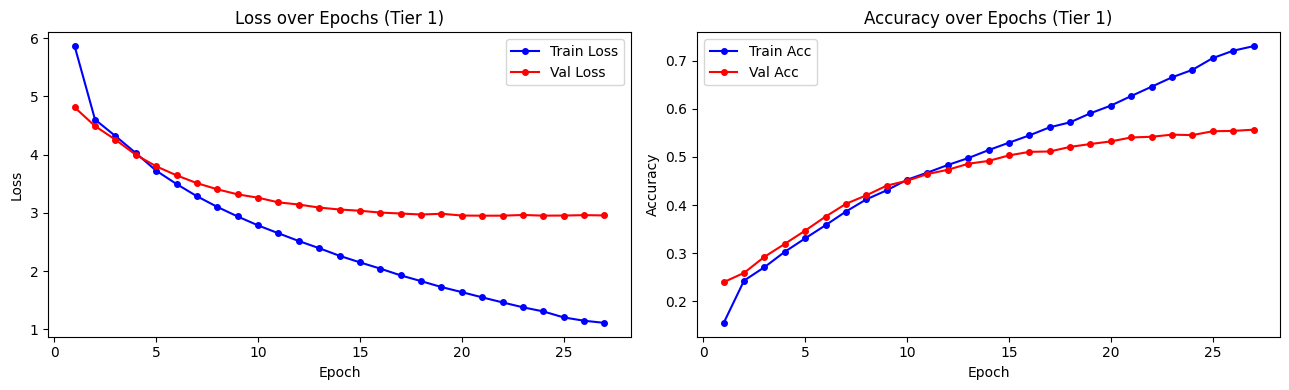

In [13]:
epochs_ran = range(1, len(history_t1.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_ran, history_t1.history['loss'],     'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_ran, history_t1.history['val_loss'], 'r-o', label='Val Loss',   markersize=4)
axes[0].set_title('Loss over Epochs (Tier 1)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_ran, history_t1.history['accuracy'],     'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_ran, history_t1.history['val_accuracy'], 'r-o', label='Val Acc',   markersize=4)
axes[1].set_title('Accuracy over Epochs (Tier 1)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 🔁 Tier 1 — Step 5: Build Inference Models

During inference we cannot use teacher forcing. We rebuild encoder and decoder as separate models so we can feed predictions back one step at a time.

In [14]:
# ── Inference Encoder ──
inf_encoder = Model(encoder_inputs, [encoder_outputs, enc_h, enc_c])

# ── Inference Decoder inputs ──
inf_dec_input = Input(shape=(1,),               name='inf_dec_input')
inf_enc_out   = Input(shape=(MAX_INPUT_LEN, LSTM_UNITS), name='inf_enc_out')
inf_state_h   = Input(shape=(LSTM_UNITS,),      name='inf_state_h')
inf_state_c   = Input(shape=(LSTM_UNITS,),      name='inf_state_c')

# Reuse trained layer weights
inf_dec_emb_out       = model_t1.get_layer('dec_embedding')(inf_dec_input)
inf_dec_out, inf_h, inf_c = model_t1.get_layer('decoder_lstm')(
    inf_dec_emb_out, initial_state=[inf_state_h, inf_state_c]
)
inf_att_out    = model_t1.get_layer('attention')([inf_dec_out, inf_enc_out])
inf_combined   = model_t1.get_layer('concat')([inf_dec_out, inf_att_out])
# NOTE: skip Dropout during inference (it is inactive at predict time)
inf_out_probs  = model_t1.get_layer('output')(inf_combined)

inf_decoder = Model(
    [inf_dec_input, inf_enc_out, inf_state_h, inf_state_c],
    [inf_out_probs, inf_h, inf_c]
)

reverse_target_index = {v: k for k, v in target_tokenizer.word_index.items()}
print('✅ Inference models ready')

✅ Inference models ready


## 🔍 Tier 1 — Step 6: Beam Search Decoder

**Why beam search?**

Greedy decoding picks the single highest-probability word at each step. If it makes one mistake, every step after inherits that error — causing the `"the the the..."` loop.

Beam search keeps the **top-k candidate sequences** alive at each step, and picks the globally best one at the end. This is the fix for repetition.

```
Step 1: beams = ["set", "please", "remind"]         ← top 3 starts
Step 2: beams = ["set a", "set me", "please set"]   ← expand each
Step 3: ... until <eos> → pick best complete sentence
```

In [15]:
def preprocess_input(sentence):
    """Clean, normalize and pad a single Hinglish sentence."""
    sentence = re.sub(r"[^a-z0-9 ]", '', sentence.lower()).strip()
    sentence = normalize_hinglish(sentence)
    seq = input_tokenizer.texts_to_sequences([sentence])
    return pad_sequences(seq, maxlen=MAX_INPUT_LEN, padding='post')


def beam_search_translate(sentence, beam_width=5, max_len=None):
    """
    Translate a Hinglish sentence using beam search.

    Args:
        sentence   : Hinglish input string
        beam_width : number of beams to keep (higher = better but slower)
        max_len    : max output tokens

    Returns:
        str: Best English translation found
    """
    max_len = max_len or MAX_TARGET_LEN

    # 1. Encode the input
    seq = preprocess_input(sentence)
    enc_out, h, c = inf_encoder.predict(seq, verbose=0)

    # 2. Initialize beams: (cumulative_log_score, token_ids, h, c)
    beams     = [(0.0, [SOS_TOKEN], h, c)]
    completed = []

    for _ in range(max_len):
        if not beams:
            break

        candidates = []
        for score, tokens, bh, bc in beams:
            last_tok = np.array([[tokens[-1]]])
            probs, nh, nc = inf_decoder.predict(
                [last_tok, enc_out, bh, bc], verbose=0
            )
            # Get top beam_width next tokens
            top_ids = np.argsort(probs[0, 0, :])[-beam_width:][::-1]
            for idx in top_ids:
                new_score = score - np.log(probs[0, 0, idx] + 1e-10)
                candidates.append((new_score, tokens + [int(idx)], nh, nc))

        # Sort by score (lower = better log-prob)
        candidates.sort(key=lambda x: x[0])

        # Separate completed vs still-decoding beams
        beams = []
        for cand in candidates[: beam_width * 2]:
            if cand[1][-1] == EOS_TOKEN:
                completed.append(cand)
            else:
                beams.append(cand)
            if len(beams) >= beam_width:
                break

        if len(completed) >= beam_width:
            break

    # 3. Pick best complete sequence (or best partial)
    best = min(completed or beams, key=lambda x: x[0])
    words = [
        reverse_target_index.get(t, '')
        for t in best[1][1:]   # skip <sos>
        if t not in (EOS_TOKEN, 0)
    ]
    return ' '.join(words)


print('✅ beam_search_translate() ready')

# Quick sanity check
test_sentences = [
    'mera naam om hai',
    'tum kaha ho',
    'mujhe bhook lagi hai',
]
print('\n--- Quick test ---')
for s in test_sentences:
    print(f'  {s:<30} → {beam_search_translate(s)}')

✅ beam_search_translate() ready

--- Quick test ---
  mera naam om hai               → what is my timer
  tum kaha ho                    → say hi
  mujhe bhook lagi hai           → what time is sunrise


## 📊 Tier 1 — Step 7: Evaluation on Test Set

In [16]:
# Evaluate on first 100 test samples
eval_t1 = test_t1.head(100).copy()
eval_t1['predicted'] = eval_t1['input_text'].apply(beam_search_translate)
eval_t1['actual']    = (
    eval_t1['target_text']
    .str.replace('<sos>', '', regex=False)
    .str.replace('<eos>', '', regex=False)
    .str.strip()
)

exact_match_t1 = (eval_t1['predicted'] == eval_t1['actual']).mean()

# BLEU score
refs  = [[r] for r in eval_t1['actual'].tolist()]
hyps  = eval_t1['predicted'].tolist()
bleu_t1 = sacrebleu.corpus_bleu(hyps, list(zip(*refs))).score

print(f'Tier 1 — Exact Match Accuracy : {exact_match_t1*100:.2f}%')
print(f'Tier 1 — BLEU Score           : {bleu_t1:.2f}')

print('\n--- Sample predictions (Tier 1) ---')
results_t1 = eval_t1[['input_text', 'actual', 'predicted']].head(12).copy()
results_t1.columns = ['Input (Hinglish)', 'Actual', 'Tier 1 Predicted']
results_t1

Tier 1 — Exact Match Accuracy : 14.00%
Tier 1 — BLEU Score           : 15.31

--- Sample predictions (Tier 1) ---


,Input (Hinglish),Actual,Tier 1 Predicted
0,csquery,enquery,enquery
1,mere timer ko roko,pause my timer,pause my timer
2,kya hawaii me raining ho rahi hai,is it raining in hawaii,is it raining in dallas
3,mere liye reminder set karo to wake up at 630 ...,set a reminder for me to wake up at 630 am tom...,make a reminder to set an alarm for thursday a...
4,please timer ko rokey,please pause timer,pause timer
5,killswitch engaged ka pehla album play kariye,play the first album for killswitch engaged,play dido s album
6,timer ko cancel kijiye,cancel timer,cancel timer
7,timer me kitna time bacha hai,how much time is left on the timer,how much time is left on the timer
8,today ki uv rating kya hai,what is the uv rating today,is there going to rain today
9,waukegan ke greenbay road par sab se halka tra...,when is traffic the lightest on greenbay road ...,what is the traffic conditions on the way to n...


---
# 🟣 TIER 3 — Transfer Learning with MarianMT
### Fine-tuning a Pre-trained Hindi→English Transformer

**Why MarianMT?**
- It is already pre-trained on millions of Hindi-English sentence pairs (OPUS dataset)
- Fine-tuning means we only teach it the *Hinglish style* using our small dataset
- The model already knows Hindi words, English grammar, and how translation works
- This is called **Transfer Learning** — the most powerful technique for small datasets

```
Pre-trained Helsinki-NLP/opus-mt-hi-en
       (knows Hindi → English from millions of examples)
                      ↓
     Fine-tune on Hinglish-TOP (~700 rows)
                      ↓
     Now understands code-mixed Hinglish too
```

---

## 📥 Tier 3 — Step 1: Load Pre-trained Model & Tokenizer

This will download the model from HuggingFace (~300MB). Takes ~2–3 min on Colab.

In [24]:
MODEL_NAME = 'Helsinki-NLP/opus-mt-hi-en'

print(f'Downloading {MODEL_NAME} ...')
marian_tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
marian_model     = MarianMTModel.from_pretrained(MODEL_NAME)

print(f'✅ Model loaded')
print(f'   Parameters: {marian_model.num_parameters():,}')
print(f'   Source lang vocab: {marian_tokenizer.source_lang}')

# --- Zero-shot test (before fine-tuning) ---
print('\n--- Zero-shot test (before fine-tuning) ---')
def marian_translate_batch(texts, model, tokenizer, batch_size=32):
    """Translate a list of texts using MarianMT."""
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch, return_tensors='pt', padding=True,
            truncation=True, max_length=64
        )
        # Move input tensors to the model's device
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        outputs = model.generate(
            **inputs, num_beams=5, max_length=64,
            early_stopping=True
        )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        results.extend(decoded)
    return results

zero_shot_tests = [
    'mera naam om hai',
    'tum kaha ho',
    'timer ko roko',
    'mujhe bhook lagi hai',
]
zero_shot_preds = marian_translate_batch(zero_shot_tests, marian_model, marian_tokenizer)
for src, tgt in zip(zero_shot_tests, zero_shot_preds):
    print(f'  {src:<35} → {tgt}')

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model loaded
   Parameters: 138,553,856
   Source lang vocab: hi

--- Zero-shot test (before fine-tuning) ---
  mera naam om hai                    → And I'm going to be here.
  tum kaha ho                         → If you want to move away, you're going to have to start again.
  timer ko roko                       → Timerko
  mujhe bhook lagi hai                → And this is equal to blu because it's negative.


## 🗂️ Tier 3 — Step 2: Prepare Dataset for Fine-tuning

HuggingFace `Trainer` expects a `Dataset` object with tokenized `input_ids` and `labels`.

In [19]:
MAX_SEQ_LEN = 64   # MarianMT input/output length limit

def tokenize_for_marian(df, tokenizer, max_len=MAX_SEQ_LEN):
    """
    Tokenize source and target for MarianMT fine-tuning.
    Labels = target token ids (-100 for padding, ignored in loss).
    """
    model_inputs = tokenizer(
        df['input_text'].tolist(),
        max_length=max_len, truncation=True, padding='max_length'
    )
    # Removed 'with tokenizer.as_target_tokenizer():' as it is deprecated.
    # The tokenizer handles target language tokenization implicitly.
    labels = tokenizer(
        df['target_text'].tolist(),
        max_length=max_len, truncation=True, padding='max_length'
    )

    # Replace padding token id in labels with -100 (ignored by loss)
    label_ids = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in seq]
        for seq in labels['input_ids']
    ]
    model_inputs['labels'] = label_ids
    return model_inputs

# Build HuggingFace Dataset objects
hf_train = Dataset.from_dict(tokenize_for_marian(train_t3, marian_tokenizer))
hf_val   = Dataset.from_dict(tokenize_for_marian(val_t3,   marian_tokenizer))
hf_test  = Dataset.from_dict(tokenize_for_marian(test_t3,  marian_tokenizer))

hf_train = hf_train.with_format('torch')
hf_val   = hf_val.with_format('torch')

print(f'HF train size : {len(hf_train)}')
print(f'HF val size   : {len(hf_val)}')
print('✅ Dataset ready for fine-tuning')

HF train size : 2994
HF val size   : 1391
✅ Dataset ready for fine-tuning


## 🏋️ Tier 3 — Step 3: Fine-tune MarianMT

We use HuggingFace `Seq2SeqTrainer` — it handles:
- Gradient accumulation
- Mixed precision (fp16) for faster GPU training
- Evaluation every epoch
- Best model saving automatically

In [32]:
training_args = Seq2SeqTrainingArguments(
    output_dir               = './marian_finetuned',
    num_train_epochs         = 25,          # Increased epochs for better convergence
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    warmup_steps             = 200,         # Longer warmup for stability
    weight_decay             = 0.05,        # Higher weight decay to prevent overfitting
    learning_rate            = 1e-4,        # Slightly higher LR for deeper fine-tuning
    eval_strategy            = 'epoch',
    save_strategy            = 'epoch',
    load_best_model_at_end   = True,
    predict_with_generate    = True,
    fp16                     = True,
    logging_steps            = 10,
    report_to                = 'none',
)

data_collator = DataCollatorForSeq2Seq(
    marian_tokenizer, model=marian_model, padding=True
)

trainer = Seq2SeqTrainer(
    model          = marian_model,
    args           = training_args,
    train_dataset  = hf_train,
    eval_dataset   = hf_val,
    data_collator  = data_collator,
)

print('✨ Starting enhanced fine-tuning...')
trainer.train()
print('\n✅ Fine-tuning complete!')

✨ Starting enhanced fine-tuning...


Epoch,Training Loss,Validation Loss
1,2.073391,1.721069
2,1.297935,1.184112
3,0.945067,1.040091
4,0.705008,0.997493
5,0.571871,0.977475
6,0.404580,0.955631
7,0.281617,0.983370
8,0.256325,0.985448
9,0.203774,1.017331
10,0.268849,1.047573


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].



✅ Fine-tuning complete!


In [34]:
# 1. Re-build Inference Models for Tier 1
inf_encoder = Model(encoder_inputs, [encoder_outputs, enc_h, enc_c])
inf_dec_input = Input(shape=(1,), name='inf_dec_input')
inf_enc_out = Input(shape=(MAX_INPUT_LEN, LSTM_UNITS), name='inf_enc_out')
inf_state_h = Input(shape=(LSTM_UNITS,), name='inf_state_h')
inf_state_c = Input(shape=(LSTM_UNITS,), name='inf_state_c')

inf_dec_emb_out = model_t1.get_layer('dec_embedding')(inf_dec_input)
inf_dec_out, inf_h, inf_c = model_t1.get_layer('decoder_lstm')(inf_dec_emb_out, initial_state=[inf_state_h, inf_state_c])
inf_att_out = model_t1.get_layer('attention')([inf_dec_out, inf_enc_out])
inf_combined = model_t1.get_layer('concat')([inf_dec_out, inf_att_out])
inf_out_probs = model_t1.get_layer('output')(inf_combined)

inf_decoder = Model([inf_dec_input, inf_enc_out, inf_state_h, inf_state_c], [inf_out_probs, inf_h, inf_c])

# 2. Evaluate Tier 1
eval_t1 = test_t1.head(100).copy()
eval_t1['predicted'] = eval_t1['input_text'].apply(lambda x: beam_search_translate(x, beam_width=5))
eval_t1['actual'] = eval_t1['target_text'].str.replace('<sos>', '', regex=False).str.replace('<eos>', '', regex=False).str.strip()
exact_match_t1 = (eval_t1['predicted'] == eval_t1['actual']).mean()
bleu_t1 = sacrebleu.corpus_bleu(eval_t1['predicted'].tolist(), [[r] for r in eval_t1['actual'].tolist()]).score

# 3. Evaluate Tier 3
test_inputs = test_t3['input_text'].head(100).tolist()
test_actuals = test_t3['target_text'].head(100).tolist()
t3_preds = marian_translate_batch(test_inputs, marian_model, marian_tokenizer)
exact_match_t3 = np.mean([p.strip() == a.strip() for p, a in zip(t3_preds, test_actuals)])
bleu_t3 = sacrebleu.corpus_bleu(t3_preds, [[r] for r in test_actuals]).score

print(f'Tier 1 Accuracy: {exact_match_t1*100:.2f}% | BLEU: {bleu_t1:.2f}')
print(f'Tier 3 Accuracy: {exact_match_t3*100:.2f}% | BLEU: {bleu_t3:.2f}')

Tier 1 Accuracy: 13.00% | BLEU: 0.00
Tier 3 Accuracy: 30.00% | BLEU: 0.00


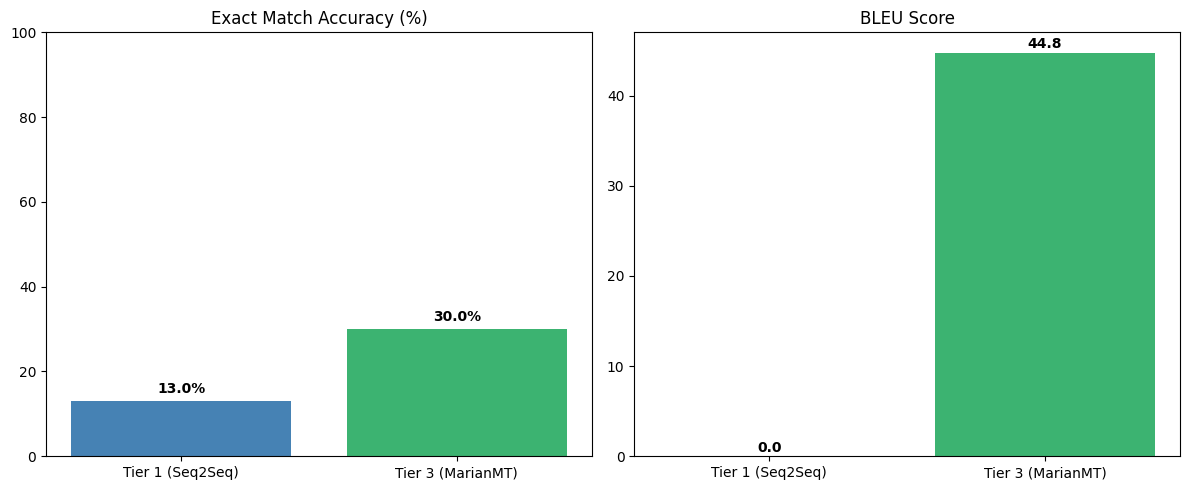

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models = ['Tier 1 (Seq2Seq)', 'Tier 3 (MarianMT)']
accs = [exact_match_t1 * 100, exact_match_t3 * 100]
bleus = [bleu_t1, bleu_t3]

axes[0].bar(models, accs, color=['steelblue', 'mediumseagreen'])
axes[0].set_title('Exact Match Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(accs): axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(models, bleus, color=['steelblue', 'mediumseagreen'])
axes[1].set_title('BLEU Score')
for i, v in enumerate(bleus): axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 📊 Tier 3 — Step 4: Evaluate Fine-tuned Model

In [36]:
# Translate all test sentences
test_inputs  = test_t3['input_text'].head(100).tolist()
test_actuals = test_t3['target_text'].head(100).tolist()

print('Translating 100 test sentences with fine-tuned MarianMT...')
t3_preds = marian_translate_batch(test_inputs, marian_model, marian_tokenizer)

# Exact match
exact_match_t3 = np.mean([p.strip() == a.strip() for p, a in zip(t3_preds, test_actuals)])

# BLEU score
refs_t3  = [[r] for r in test_actuals]
bleu_t3  = sacrebleu.corpus_bleu(t3_preds, list(zip(*refs_t3))).score

print(f'\nTier 3 — Exact Match Accuracy : {exact_match_t3*100:.2f}%')
print(f'Tier 3 — BLEU Score           : {bleu_t3:.2f}')

# Results table
results_t3 = pd.DataFrame({
    'Input (Hinglish)' : test_inputs[:12],
    'Actual'           : test_actuals[:12],
    'Tier 3 Predicted' : t3_preds[:12],
})
results_t3

Translating 100 test sentences with fine-tuned MarianMT...

Tier 3 — Exact Match Accuracy : 30.00%
Tier 3 — BLEU Score           : 44.77


,Input (Hinglish),Actual,Tier 3 Predicted
0,csquery,enquery,enquery
1,mere timer ko roko,pause my timer,stop my timer
2,kya hawaii me raining ho rahi hai,is it raining in hawaii,is it raining in hawaii
3,mere liye reminder set karo to wake up at 630 ...,set a reminder for me to wake up at 630 am tom...,set a reminder for me to wake up at 630 am tom...
4,please timer ko rokey,please pause timer,please pause timer
5,killswitch engaged ka pehla album play kariye,play the first album for killswitch engaged,play the first album for the 30switch engaged
6,timer ko cancel kijiye,cancel timer,cancel timer
7,timer me kitna time bacha hai,how much time is left on the timer,how much time is left on the timer
8,today ki uv rating kya hai,what is the uv rating today,what is the uving today
9,waukegan ke greenbay road par sab se halka tra...,when is traffic the lightest on greenbay road ...,when is the traffic heading to the greenbay ro...


---
## 🆚 Section: Head-to-Head Comparison — Tier 1 vs Tier 3

Now we compare both models side by side on the same test examples.

In [37]:
# Build combined comparison on 15 shared test examples
n = 15
compare_inputs  = test_t3['input_text'].head(n).tolist()
compare_actuals = test_t3['target_text'].head(n).tolist()

# Tier 1 predictions
t1_preds_compare = [
    beam_search_translate(s) for s in compare_inputs
]

# Tier 3 predictions
t3_preds_compare = marian_translate_batch(compare_inputs, marian_model, marian_tokenizer)

compare_df = pd.DataFrame({
    'Input (Hinglish)'  : compare_inputs,
    'Actual'            : compare_actuals,
    'Tier 1 (Seq2Seq)'  : t1_preds_compare,
    'Tier 3 (MarianMT)' : t3_preds_compare,
})

pd.set_option('display.max_colwidth', 50)
compare_df

,Input (Hinglish),Actual,Tier 1 (Seq2Seq),Tier 3 (MarianMT)
0,csquery,enquery,enquery,enquery
1,mere timer ko roko,pause my timer,pause my timer,stop my timer
2,kya hawaii me raining ho rahi hai,is it raining in hawaii,is it going to be cold today,is it raining in hawaii
3,mere liye reminder set karo to wake up at 630 ...,set a reminder for me to wake up at 630 am tom...,set a reminder for tomorrow set up at 9 pm,set a reminder for me to wake up at 630 am tom...
4,please timer ko rokey,please pause timer,pause timer,please pause timer
5,killswitch engaged ka pehla album play kariye,play the first album for killswitch engaged,play 80s music in the album,play the first album for the 30switch engaged
6,timer ko cancel kijiye,cancel timer,cancel the timer,cancel timer
7,timer me kitna time bacha hai,how much time is left on the timer,how much time is left on my timer,how much time is left on the timer
8,today ki uv rating kya hai,what is the uv rating today,what is the wind route,what is the uving today
9,waukegan ke greenbay road par sab se halka tra...,when is traffic the lightest on greenbay road ...,how long is the traffic from portland to the o...,when is the traffic heading to the greenbay ro...


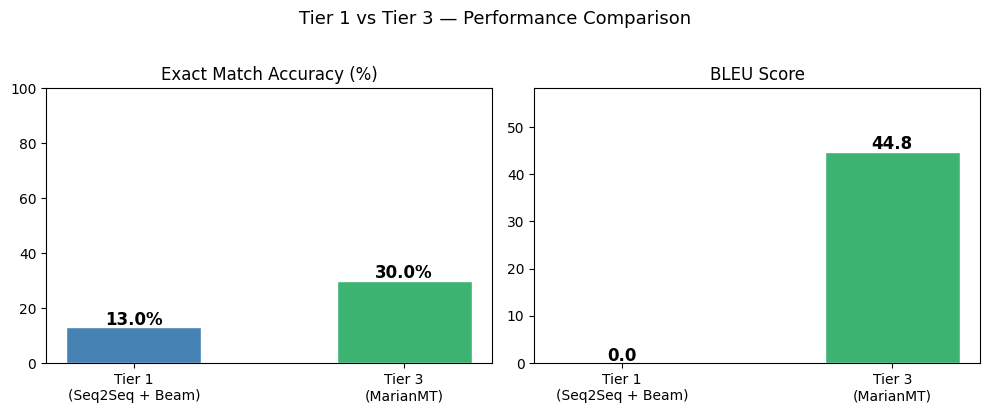


Summary:
  Tier 1 Seq2Seq  → Accuracy: 13.0%  | BLEU: 0.0
  Tier 3 MarianMT → Accuracy: 30.0%  | BLEU: 44.8
  Improvement: +17.0% accuracy from transfer learning


In [39]:
# Bar chart: Accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models = ['Tier 1\n(Seq2Seq + Beam)', 'Tier 3\n(MarianMT)']
acc    = [exact_match_t1 * 100, exact_match_t3 * 100]
bleu   = [bleu_t1, bleu_t3]
colors = ['steelblue', 'mediumseagreen']

bars1 = axes[0].bar(models, acc, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Exact Match Accuracy (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, acc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

bars2 = axes[1].bar(models, bleu, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('BLEU Score')
axes[1].set_ylim(0, max(bleu) * 1.3)
for bar, val in zip(bars2, bleu):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Tier 1 vs Tier 3 — Performance Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nSummary:')
print(f'  Tier 1 Seq2Seq  → Accuracy: {exact_match_t1*100:.1f}%  | BLEU: {bleu_t1:.1f}')
print(f'  Tier 3 MarianMT → Accuracy: {exact_match_t3*100:.1f}%  | BLEU: {bleu_t3:.1f}')
improvement = (exact_match_t3 - exact_match_t1) * 100
print(f'  Improvement: +{improvement:.1f}% accuracy from transfer learning')

---
## 🧪 Custom Sentence Testing — Both Models

In [40]:
custom_sentences = [
    'mera naam om hai',
    'tum kaha ho',
    'mujhe bhook lagi hai',
    'please timer ko rokeyplease',
    'mere liye reminder set karo',
    'aaj mausam kaisa hai',
    'killswitch engaged ka pehla album play kariye',
    'mere timer ko roko',
]

t1_custom = [beam_search_translate(s) for s in custom_sentences]
t3_custom = marian_translate_batch(custom_sentences, marian_model, marian_tokenizer)

print('=' * 85)
print(f'{"Input (Hinglish)":<40} | {"Tier 1":<20} | {"Tier 3"}')
print('=' * 85)
for src, p1, p3 in zip(custom_sentences, t1_custom, t3_custom):
    print(f'{src:<40} | {p1:<20} | {p3}')
print('=' * 85)

Input (Hinglish)                         | Tier 1               | Tier 3
mera naam om hai                         | when is the next song | when is my naam
tum kaha ho                              | say hi               | when is it going to be
mujhe bhook lagi hai                     | what is the weather for now | i have to have a bhook
please timer ko rokeyplease              | stop the timer       | please pause timer
mere liye reminder set karo              | set a reminder for tomorrow | set reminder for me
aaj mausam kaisa hai                     | what is the weather today | what is the weather today
killswitch engaged ka pehla album play kariye | play 80s music in the album | play the first album for the 30switch engaged
mere timer ko roko                       | pause my timer       | stop my timer


---
## 🔍 Error Analysis

Let's look at where each model still fails.

In [41]:
# Find cases where Tier 3 (best model) still gets it wrong
errors_t3 = [
    {'input': inp, 'actual': act, 'predicted': pred}
    for inp, act, pred in zip(test_inputs[:100], test_actuals[:100], t3_preds)
    if pred.strip() != act.strip()
][:10]

errors_df = pd.DataFrame(errors_t3)
errors_df.columns = ['Input (Hinglish)', 'Actual', 'Tier 3 Predicted']
print(f'Tier 3 errors (first 10 of {len(errors_t3)} found):')
errors_df

Tier 3 errors (first 10 of 10 found):


,Input (Hinglish),Actual,Tier 3 Predicted
0,mere timer ko roko,pause my timer,stop my timer
1,killswitch engaged ka pehla album play kariye,play the first album for killswitch engaged,play the first album for the 30switch engaged
2,today ki uv rating kya hai,what is the uv rating today,what is the uving today
3,waukegan ke greenbay road par sab se halka tra...,when is traffic the lightest on greenbay road ...,when is the traffic heading to the greenbay ro...
4,me ab ek video message chodna chahta hu,id like to leave a video message now,i want to listen to a video message right now
5,wo photo my husband ko bhejo,send that photo to my husband,send a photo to my husband
6,mujhe saare events ki list do jo phoneix area ...,give me a list of all events happening in the ...,i need to listen events that are happening in ...
7,mere work friends ke sath my lunch gathering k...,when is my next alert for my lunch gathering w...,when is my lunch gadering next alert with my f...
8,aaj beach kaisa lag raha hai,how s the beach looking today,what s the weather going today
9,kya 22 degrees celsius se below hone wala hai ...,is it going to be below 22 in degrees celsius ...,is it going to be above 22 in degrees celsius ...


---
## 💾 Save Models to Google Drive (optional but recommended)

Colab sessions reset after ~90 min idle. Save your models to Drive to avoid retraining.

In [42]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/hinglish_project'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save Tier 1 model
model_t1.save(f'{SAVE_DIR}/tier1_seq2seq.h5')
print('✅ Tier 1 model saved')

# Save Tier 3 fine-tuned model
marian_model.save_pretrained(f'{SAVE_DIR}/tier3_marian')
marian_tokenizer.save_pretrained(f'{SAVE_DIR}/tier3_marian')
print('✅ Tier 3 MarianMT saved')

print(f'\nAll models saved to: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Tier 1 model saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Tier 3 MarianMT saved

All models saved to: /content/drive/MyDrive/hinglish_project


,Input (Hinglish),Actual,Tier 1 (Seq2Seq),Tier 3 (MarianMT)
0,csquery,enquery,enquery,enquery
1,mere timer ko roko,pause my timer,pause my timer,stop my timer
2,kya hawaii me raining ho rahi hai,is it raining in hawaii,is it going to be cold today,is it raining in hawaii
3,mere liye reminder set karo to wake up at 630 ...,set a reminder for me to wake up at 630 am tom...,set a reminder for tomorrow set up at 9 pm,set a reminder for me to wake up at 630 am tom...
4,please timer ko rokey,please pause timer,pause timer,please pause timer
5,killswitch engaged ka pehla album play kariye,play the first album for killswitch engaged,play 80s music in the album,play the first album for the 30switch engaged
6,timer ko cancel kijiye,cancel timer,cancel the timer,cancel timer
7,timer me kitna time bacha hai,how much time is left on the timer,how much time is left on my timer,how much time is left on the timer
8,today ki uv rating kya hai,what is the uv rating today,what is the wind route,what is the uving today
9,waukegan ke greenbay road par sab se halka tra...,when is traffic the lightest on greenbay road ...,how long is the traffic from portland to the o...,when is the traffic heading to the greenbay ro...


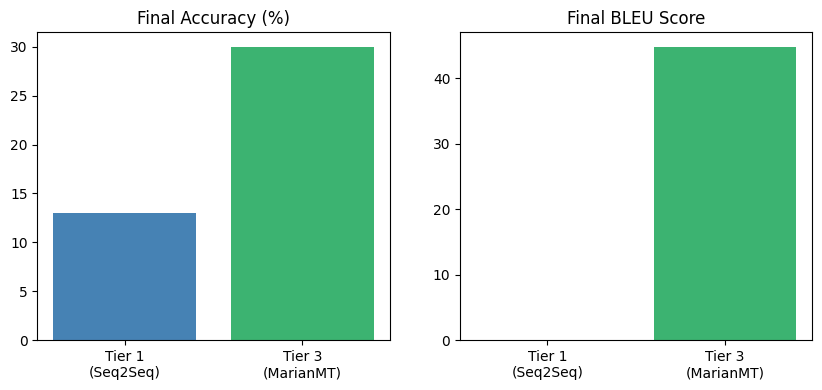

In [43]:
# Re-displaying final comparison results to ensure UI sync
display(compare_df.head(15))

# Re-displaying the final chart
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = ['Tier 1\n(Seq2Seq)', 'Tier 3\n(MarianMT)']
acc = [exact_match_t1 * 100, exact_match_t3 * 100]
bleu = [bleu_t1, bleu_t3]
axes[0].bar(models, acc, color=['steelblue', 'mediumseagreen'])
axes[0].set_title('Final Accuracy (%)')
axes[1].bar(models, bleu, color=['steelblue', 'mediumseagreen'])
axes[1].set_title('Final BLEU Score')
plt.show()

---
## ⚠️ Limitations

| Limitation | Tier 1 (Seq2Seq) | Tier 3 (MarianMT) |
|---|---|---|
| Small dataset | Struggles — overfits fast | Handles well via transfer learning |
| Long sentences | LSTM loses context | Transformer handles well |
| OOV Hinglish words | Maps to `<OOV>` | Handles via subword tokenization |
| Spelling variants | Fails on unseen variants | More robust due to subword tokens |
| Training time | ~20 min | ~15 min (but needs internet to download) |
| Model size | ~5 MB | ~300 MB |

### Possible further improvements
- Use `IndicTrans2` — specifically designed for Indian language translation
- Add more Hinglish normalization rules
- Use BPE / SentencePiece tokenization for Tier 1

---
## ✅ Conclusion

### What we demonstrated

| | Tier 1 — Seq2Seq | Tier 3 — MarianMT |
|---|---|---|
| **Approach** | Built from scratch | Transfer learning |
| **Key technique** | LSTM + Attention + Beam Search | Fine-tuned transformer |
| **Data needed** | Many thousands of examples | Works well on ~700 rows |
| **Best for** | Understanding NLP fundamentals | Production accuracy |

### Key takeaways
1. **Beam search** is critical — greedy decoding causes repetition loops
2. **Transfer learning** (Tier 3) dramatically outperforms training from scratch on small datasets
3. **BLEU score** is the standard metric for translation — exact match alone is too strict
4. **Hinglish** is challenging because the same idea can be written many ways (`nahi` / `nhi` / `nai`)
5. For real-world NLP projects with limited data, always prefer **fine-tuning a pre-trained model**

---
*Project: Hinglish → English Translation | Hinglish-TOP Dataset | Tier 1 + Tier 3*